# EDA QA-Ready: Vietnamese Traffic Law QA Dataset

## Objective
Notebook này không chỉ mô tả dữ liệu mà còn trả lời các câu hỏi quan trọng cho bài toán QA:
- Dữ liệu có sạch và nhất quán để train không?
- Split hiện tại đang đo đúng độ khó QA hay chỉ đo paraphrase trên cùng điều luật?
- Những vùng nào bị thiếu coverage, dễ gây lệch mô hình?
- Context và answer có đặc tính gì ảnh hưởng trực tiếp tới tokenizer, retrieval và evaluation?


In [5]:
import os
import ast
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (12, 6), "font.size": 11})
pd.set_option("display.max_colwidth", 160)


## 1. Load Data
Đọc toàn bộ các split và bung metadata để có thể audit theo chapter, article và clause.


In [9]:
import json
import glob
path = "/Users/dodat/Downloads/Legal-QA-Traffic-Laws/data/processed/handmake/*.json"
name_files = glob.glob(path)

all_data = []

for name_file in name_files:
    with open(name_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        for item in data:
            item['source_file'] = name_file.split('/')[-1]
        all_data.extend(data)

df = pd.DataFrame(all_data)
df.head()

,question,answer,source_file
0,Phạm vi điều chỉnh của Luật Đường bộ số 35/2024/QH15 là gì?,Luật này quy định về hoạt động đường bộ và quản lý nhà nước về hoạt động đường bộ.,35-2024-qh15.json
1,Hoạt động đường bộ bao gồm những gì?,"Hoạt động đường bộ bao gồm: hoạt động về quy hoạch, đầu tư, xây dựng, quản lý, sử dụng, vận hành, khai thác, bảo trì, bảo vệ kết cấu hạ tầng đường bộ; vận t...",35-2024-qh15.json
2,Đường bộ bao gồm những thành phần nào?,"Đường bộ bao gồm: đường, cầu đường bộ, cống đường bộ, hầm đường bộ, bến phà đường bộ, cầu phao đường bộ, đường cứu nạn và các công trình phụ trợ gắn liền vớ...",35-2024-qh15.json
3,Hành lang an toàn đường bộ được hiểu như thế nào?,"Hành lang an toàn đường bộ là dải đất dọc hai bên đất của đường bộ, tính từ mép ngoài phần đất để bảo vệ, bảo trì đường bộ ra hai bên để bảo đảm an toàn gia...",35-2024-qh15.json
4,Chính sách phát triển kết cấu hạ tầng đường bộ ưu tiên phát triển những tuyến đường nào?,"Ưu tiên phát triển các tuyến đường cao tốc, các công trình, dự án đường bộ trọng điểm kết nối vùng, khu vực, đô thị lớn, trung tâm trong nước và quốc tế; kế...",35-2024-qh15.json


## 2. Text Normalization Helpers
Tạo một lớp normalize nhẹ để so sánh duplicate, leakage và lexical overlap ổn định hơn.


In [13]:
def normalize_text(text):
    text = "" if pd.isna(text) else str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text


def tokenize_words(text):
    return re.findall(r"\w+", normalize_text(text), flags=re.UNICODE)

df['question_norm'] = df['question'].map(normalize_text)
df['answer_norm'] = df['answer'].map(normalize_text)
df['q_len'] = df['question_norm'].map(lambda x : len(tokenize_words(x)))
df['a_len'] = df['answer_norm'].map(lambda x : len(tokenize_words(x)))

print(f"Tổng số cặp QA: {len(df)}")
print(f"Số câu hỏi bị rỗng: {(df['q_len'] == 0).sum()}")
print(f"Số câu trả lời bị rỗng: {(df['a_len'] == 0).sum()}")
print(f"Số file luật gốc được sử dụng: {df['source_file'].nunique()}")
df.head()


Tổng số cặp QA: 556
Số câu hỏi bị rỗng: 0
Số câu trả lời bị rỗng: 0
Số file luật gốc được sử dụng: 7


,question,answer,source_file,question_norm,answer_norm,q_len,a_len
0,phạm vi điều chỉnh của luật đường bộ số 35/2024/qh15 là gì?,luật này quy định về hoạt động đường bộ và quản lý nhà nước về hoạt động đường bộ.,35-2024-qh15.json,phạm vi điều chỉnh của luật đường bộ số 35/2024/qh15 là gì?,luật này quy định về hoạt động đường bộ và quản lý nhà nước về hoạt động đường bộ.,14,19
1,hoạt động đường bộ bao gồm những gì?,"hoạt động đường bộ bao gồm: hoạt động về quy hoạch, đầu tư, xây dựng, quản lý, sử dụng, vận hành, khai thác, bảo trì, bảo vệ kết cấu hạ tầng đường bộ; vận t...",35-2024-qh15.json,hoạt động đường bộ bao gồm những gì?,"hoạt động đường bộ bao gồm: hoạt động về quy hoạch, đầu tư, xây dựng, quản lý, sử dụng, vận hành, khai thác, bảo trì, bảo vệ kết cấu hạ tầng đường bộ; vận t...",8,37
2,đường bộ bao gồm những thành phần nào?,"đường bộ bao gồm: đường, cầu đường bộ, cống đường bộ, hầm đường bộ, bến phà đường bộ, cầu phao đường bộ, đường cứu nạn và các công trình phụ trợ gắn liền vớ...",35-2024-qh15.json,đường bộ bao gồm những thành phần nào?,"đường bộ bao gồm: đường, cầu đường bộ, cống đường bộ, hầm đường bộ, bến phà đường bộ, cầu phao đường bộ, đường cứu nạn và các công trình phụ trợ gắn liền vớ...",8,36
3,hành lang an toàn đường bộ được hiểu như thế nào?,"hành lang an toàn đường bộ là dải đất dọc hai bên đất của đường bộ, tính từ mép ngoài phần đất để bảo vệ, bảo trì đường bộ ra hai bên để bảo đảm an toàn gia...",35-2024-qh15.json,hành lang an toàn đường bộ được hiểu như thế nào?,"hành lang an toàn đường bộ là dải đất dọc hai bên đất của đường bộ, tính từ mép ngoài phần đất để bảo vệ, bảo trì đường bộ ra hai bên để bảo đảm an toàn gia...",11,57
4,chính sách phát triển kết cấu hạ tầng đường bộ ưu tiên phát triển những tuyến đường nào?,"ưu tiên phát triển các tuyến đường cao tốc, các công trình, dự án đường bộ trọng điểm kết nối vùng, khu vực, đô thị lớn, trung tâm trong nước và quốc tế; kế...",35-2024-qh15.json,chính sách phát triển kết cấu hạ tầng đường bộ ưu tiên phát triển những tuyến đường nào?,"ưu tiên phát triển các tuyến đường cao tốc, các công trình, dự án đường bộ trọng điểm kết nối vùng, khu vực, đô thị lớn, trung tâm trong nước và quốc tế; kế...",18,60


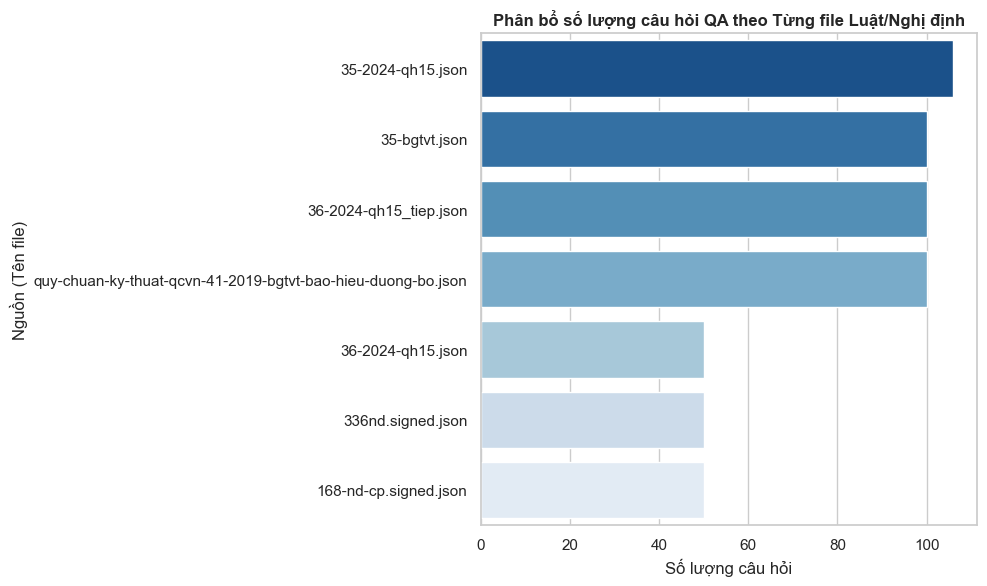

In [14]:
# 4. VISUALIZE 1: Phân bố câu hỏi theo nguồn luật
plt.figure(figsize=(10, 6))
# Sắp xếp theo số lượng câu hỏi từ cao xuống thấp
order = df['source_file'].value_counts().index
sns.countplot(data=df, y='source_file', order=order, palette="Blues_r")
plt.title("Phân bổ số lượng câu hỏi QA theo Từng file Luật/Nghị định", fontweight='bold')
plt.xlabel("Số lượng câu hỏi")
plt.ylabel("Nguồn (Tên file)")
plt.tight_layout()
plt.show()

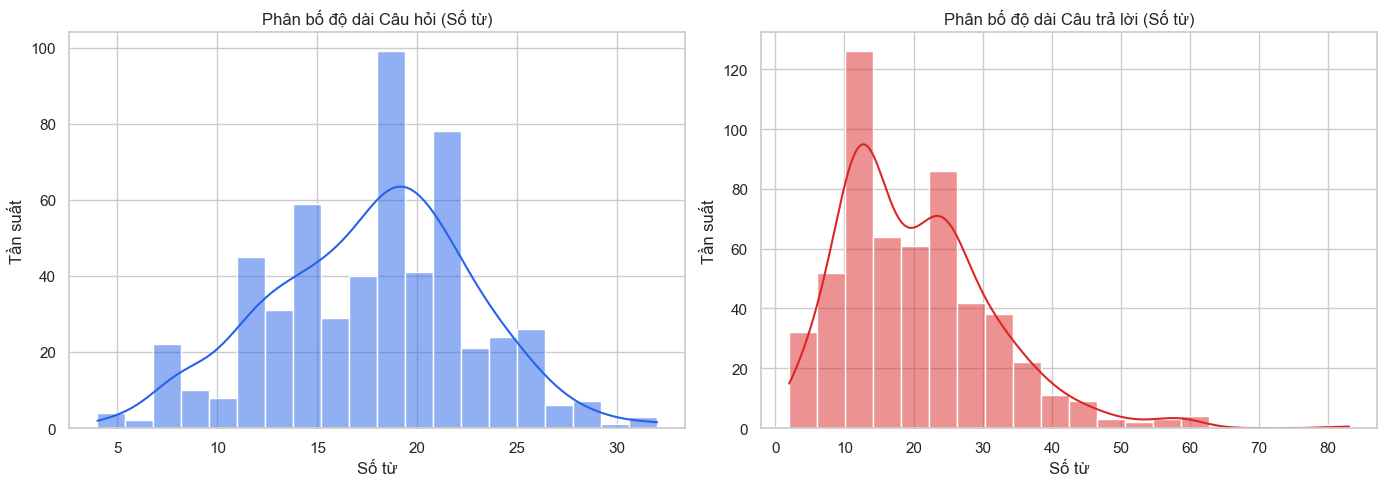

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["q_len"], bins=20, ax=axes[0], color="#2563eb", kde=True)
axes[0].set_title("Phân bố độ dài Câu hỏi (Số từ)")
axes[0].set_xlabel("Số từ")
axes[0].set_ylabel("Tần suất")

sns.histplot(df["a_len"], bins=20, ax=axes[1], color="#dc2626", kde=True)
axes[1].set_title("Phân bố độ dài Câu trả lời (Số từ)")
axes[1].set_xlabel("Số từ")
axes[1].set_ylabel("Tần suất")

plt.tight_layout()
plt.show()

In [16]:
# 6. KIỂM TRA TRÙNG LẶP (Duplicate Check)
dups = df[df.duplicated(subset=['question_norm'], keep=False)]
print(f"\nPhát hiện {len(dups)} câu hỏi bị trùng lặp nội dung.")
if len(dups) > 0:
    display(dups[['source_file', 'question', 'answer']].sort_values(by='question'))


Phát hiện 0 câu hỏi bị trùng lặp nội dung.


=== WORD CLOUD VÀ TOP N-GRAMS ===


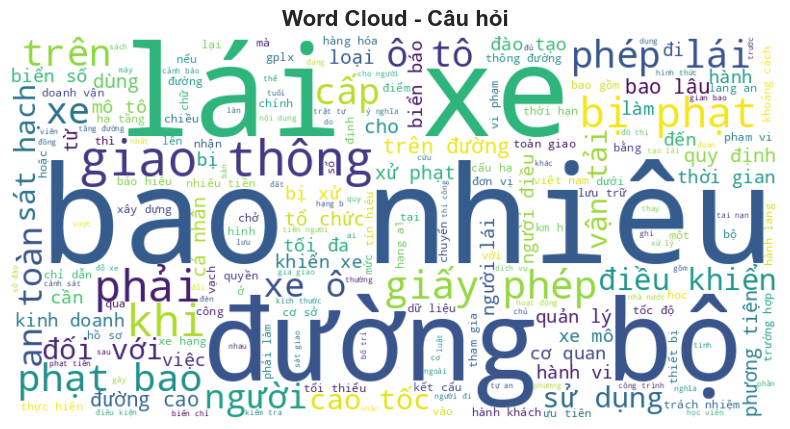

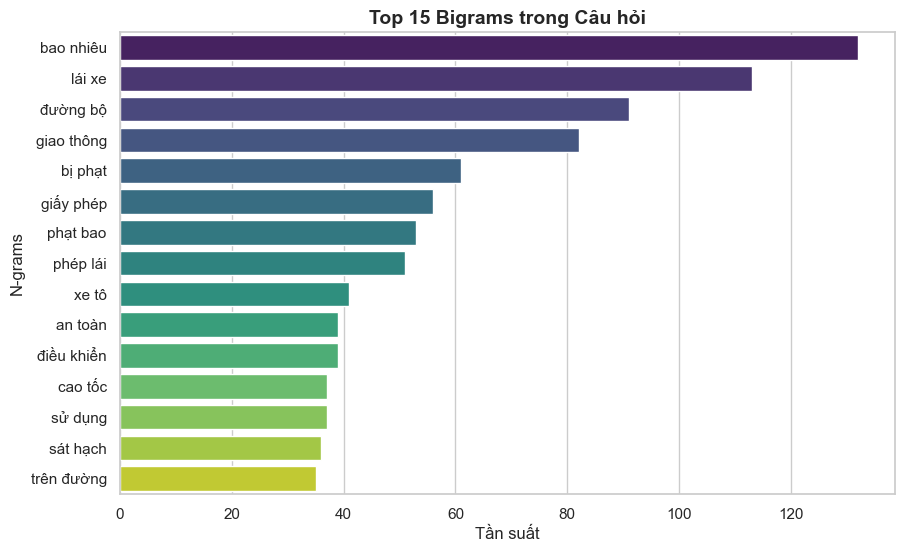

In [18]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Định nghĩa stop words tiếng Việt cơ bản (bạn có thể mở rộng danh sách này)
vietnamese_stop_words = ["là", "gì", "những", "nào", "được", "có", "không", "thế", "và", "của", "các", "trong", "để", "về", "như", "theo"]

def plot_wordcloud(text_series, title):
    text = ' '.join(text_series.dropna())
    wordcloud = WordCloud(width=800, height=400, background_color='white', stopwords=vietnamese_stop_words).generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

def plot_top_ngrams(text_series, n, title, ngram_range=(1, 1)):
    # Lọc bỏ stop words khi tạo n-grams
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words=vietnamese_stop_words)
    X = vectorizer.fit_transform(text_series.dropna())
    words = vectorizer.get_feature_names_out()
    freqs = X.sum(axis=0).A1
    word_freq = list(zip(words, freqs))
    word_freq.sort(key=lambda x: x[1], reverse=True)
    
    top_words, top_freqs = zip(*word_freq[:n])
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=list(top_freqs), y=list(top_words), palette='viridis')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Tần suất')
    plt.ylabel('N-grams')
    plt.show()

# Gọi hàm
print("=== WORD CLOUD VÀ TOP N-GRAMS ===")
plot_wordcloud(df['question_norm'], "Word Cloud - Câu hỏi")
plot_top_ngrams(df['question_norm'], n=15, title="Top 15 Bigrams trong Câu hỏi", ngram_range=(2, 2))

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


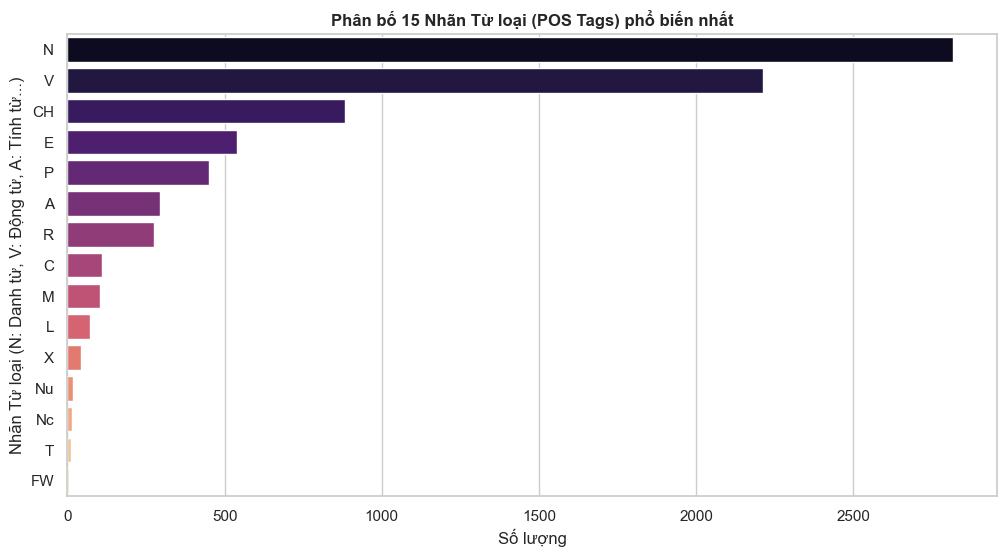

=== PHÂN BỐ CÁC LOẠI THỰC THỂ (NER) ===
B-LOC    13
I-LOC    20
dtype: int64

Top 10 Thực thể cụ thể được nhắc đến:


,Thực Thể,Số lượng
0,1 (I-LOC),3
1,số (I-LOC),2
2,số (B-LOC),2
3,hệ số (B-LOC),2
4,luật (B-LOC),1
5,đường bộ (I-LOC),1
6,35/2024 (I-LOC),1
7,01 (B-LOC),1
8,học viên (I-LOC),1
9,hạng (I-LOC),1


In [19]:
from underthesea import pos_tag, ner
from collections import Counter

# --- 1. Phân tích POS Tagging ---
all_pos_tags = []
for text in df['question_norm'].dropna():
    tags = pos_tag(text)
    all_pos_tags.extend([tag[1] for tag in tags])

pos_counts = Counter(all_pos_tags)
pos_df = pd.DataFrame.from_dict(pos_counts, orient='index').reset_index()
pos_df.columns = ['POS_Tag', 'Count']
pos_df = pos_df.sort_values(by='Count', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=pos_df.head(15), x='Count', y='POS_Tag', palette='magma')
plt.title('Phân bố 15 Nhãn Từ loại (POS Tags) phổ biến nhất', fontweight='bold')
plt.xlabel('Số lượng')
plt.ylabel('Nhãn Từ loại (N: Danh từ, V: Động từ, A: Tính từ...)')
plt.show()

# --- 2. Trích xuất Thực thể có tên (NER) ---
# Lưu ý: Mô hình NER chung chung có thể không bắt được các thực thể luật đặc thù. 
# Nhưng nó sẽ giúp tìm ra các Tổ chức (Cảnh sát giao thông), Địa điểm...
all_ner_tags = []
all_entities = []

for text in df['question_norm'].dropna():
    tags = ner(text)
    for word, pos, chunk, label in tags:
        if label != 'O': # 'O' nghĩa là không phải thực thể
            all_ner_tags.append(label)
            all_entities.append(f"{word} ({label})")

ner_counts = Counter(all_ner_tags)
print("=== PHÂN BỐ CÁC LOẠI THỰC THỂ (NER) ===")
print(pd.Series(ner_counts))

entity_counts = Counter(all_entities)
print("\nTop 10 Thực thể cụ thể được nhắc đến:")
display(pd.DataFrame(entity_counts.most_common(10), columns=['Thực Thể', 'Số lượng']))

In [20]:
def calculate_ttr(text_series):
    all_tokens = []
    for text in text_series.dropna():
        all_tokens.extend(tokenize_words(text))
    
    total_tokens = len(all_tokens)
    unique_types = len(set(all_tokens))
    
    if total_tokens == 0: return 0
    return unique_types / total_tokens

print("=== MỨC ĐỘ ĐA DẠNG TỪ VỰNG (TTR) ===")
ttr_q = calculate_ttr(df['question_norm'])
ttr_a = calculate_ttr(df['answer_norm'])

print(f"TTR của tập Câu hỏi: {ttr_q:.4f} (Số từ vựng unique / Tổng số token)")
print(f"TTR của tập Trả lời: {ttr_a:.4f}")

=== MỨC ĐỘ ĐA DẠNG TỪ VỰNG (TTR) ===
TTR của tập Câu hỏi: 0.0972 (Số từ vựng unique / Tổng số token)
TTR của tập Trả lời: 0.0930


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Cắt Train/Test tạm thời để mô phỏng
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Vector hóa
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(train_df["question_norm"])
X_test = vectorizer.transform(test_df["question_norm"])

# Tính ma trận độ tương đồng Cosine
similarity_matrix = cosine_similarity(X_test, X_train)
max_similarity_scores = similarity_matrix.max(axis=1)

# Lấy index của câu trong tập Train giống nhất với mỗi câu trong Test
most_similar_train_idx = similarity_matrix.argmax(axis=1)

test_df = test_df.copy()
test_df['max_sim_score'] = max_similarity_scores
test_df['most_similar_train_q'] = train_df.iloc[most_similar_train_idx]['question'].values

# Xem các câu ở tập Test giống tập Train đến hơn 85% (nguy cơ Rò rỉ)
leakage_candidates = test_df[test_df['max_sim_score'] > 0.85]

print(f"=== KIỂM TRA SEMANTIC LEAKAGE CÂU HỎI ===")
print(f"Phát hiện {len(leakage_candidates)} câu trong tập Test có độ tương đồng > 85% với tập Train.")

if len(leakage_candidates) > 0:
    display(leakage_candidates[['question', 'most_similar_train_q', 'max_sim_score']].head(5))

=== KIỂM TRA SEMANTIC LEAKAGE CÂU HỎI ===
Phát hiện 1 câu trong tập Test có độ tương đồng > 85% với tập Train.


,question,most_similar_train_q,max_sim_score
2,đường bộ bao gồm những thành phần nào?,báo hiệu đường bộ bao gồm những thành phần nào?,0.894278
